In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# 1. Load Data

In [63]:
sales = pd.read_csv('../data/sales_data.csv')
product = pd.read_csv('../data/product_info.csv')
customer = pd.read_csv('../data/customer_info.csv')

In [64]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          2999 non-null   object 
 1   customer_id       2998 non-null   object 
 2   product_id        2995 non-null   object 
 3   quantity          2997 non-null   object 
 4   unit_price        2999 non-null   float64
 5   order_date        2997 non-null   object 
 6   delivery_status   2997 non-null   object 
 7   payment_method    2997 non-null   object 
 8   region            3000 non-null   object 
 9   discount_applied  2483 non-null   float64
dtypes: float64(2), object(8)
memory usage: 234.5+ KB


In [65]:
product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   product_id     30 non-null     object 
 1   product_name   30 non-null     object 
 2   category       30 non-null     object 
 3   launch_date    30 non-null     object 
 4   base_price     30 non-null     float64
 5   supplier_code  30 non-null     object 
dtypes: float64(1), object(5)
memory usage: 1.5+ KB


In [66]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   customer_id   497 non-null    object
 1   email         494 non-null    object
 2   signup_date   496 non-null    object
 3   gender        496 non-null    object
 4   region        497 non-null    object
 5   loyalty_tier  498 non-null    object
dtypes: object(6)
memory usage: 23.6+ KB


In [67]:
sales.head()

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region,discount_applied
0,O966977,C00397,P0022,3,39.25,06-07-25,Delivered,PayPal,Central,0.00
1,O696648,C00236,P0023,5,18.92,06-07-25,DELAYED,credit card,North,0.00
2,O202644,C00492,P0011,1,29.68,06-07-25,delivered,Bank Transfer,North,0.15
3,O501803,C00031,P0003,1,32.76,06-07-25,Cancelled,Credit Card,Central,0.20
4,O322242,C00495,P0016,1,47.62,06-07-25,DELAYED,Credit Card,West,0.20


In [68]:
product.head()

,product_id,product_name,category,launch_date,base_price,supplier_code
0,P0001,Storage Product 39,Storage,11-03-25,15.88,S339
1,P0002,Cleaning Product 82,Cleaning,18-08-24,34.23,S974
2,P0003,Cleaning Product 85,Cleaning,15-07-24,7.92,S745
3,P0004,Kitchen Product 82,Kitchen,19-04-25,9.13,S589
4,P0005,Personal Care Product 1,Personal Care,20-10-24,31.10,S559


In [69]:
customer.head()

,customer_id,email,signup_date,gender,region,loyalty_tier
0,C00001,shaneramirez@gmail.com,26-04-25,Male,Central,Silver
1,C00002,jpeterson@bernard.com,11-08-24,Female,Central,gold
2,C00003,howardmaurice@yahoo.com,15-05-25,male,Central,gold
3,C00004,yherrera@arnold.org,14-06-25,FEMALE,Central,GOLD
4,C00005,janetwilliams@gmail.com,02-05-25,Male,West,bronze


# 2. Clean Data

In [70]:
# Standardise text columns
for df, cols in [
    (sales, ['delivery_status','payment_method','region']),
    (product, ['category']),
    (customer, ['gender','region','loyalty_tier'])
]:
  for col in cols:
    df[col] = df[col].astype(str).str.strip().str.title()

In [71]:
# Convert date columns
for df, col in [
    (sales, 'order_date'),
    (product, 'launch_date'),
    (customer, 'signup_date')
]:
  df[col] = pd.to_datetime(df[col], errors='coerce')

/var/folders/cg/3l7zwjtx4kx5vrx5x2r20btm0000gn/T/ipykernel_47407/2588452800.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
/var/folders/cg/3l7zwjtx4kx5vrx5x2r20btm0000gn/T/ipykernel_47407/2588452800.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')


In [72]:
sales.isnull().sum()

order_id              1
customer_id           2
product_id            5
quantity              3
unit_price            1
order_date            3
delivery_status       0
payment_method        0
region                0
discount_applied    517
dtype: int64

Droped because missing any of these key IDs breaks tracking and joins, so those rows can't be relibly used

In [73]:
sales = sales.dropna(subset=['order_id', 'customer_id', 'product_id'])

In [74]:
product.isnull().sum()

product_id       0
product_name     0
category         0
launch_date      0
base_price       0
supplier_code    0
dtype: int64

In [75]:
customer.isnull().sum()

customer_id     3
email           6
signup_date     4
gender          0
region          0
loyalty_tier    0
dtype: int64

In [76]:
customer = customer.dropna(subset='customer_id')

In [77]:
# Handle missing values
sales.loc[:, 'discount_applied'] = sales['discount_applied'].fillna(0.0)

# Fill missing quantity with the overall median
sales.loc[:, 'quantity'] = pd.to_numeric(sales['quantity'], errors='coerce')
sales.loc[:, 'quantity'].fillna(sales['quantity'].median(), inplace=True)

# Impute missing email with a placeholder
customer.loc[:, 'email'].fillna('no_email_provided@example.com', inplace=True)

/var/folders/cg/3l7zwjtx4kx5vrx5x2r20btm0000gn/T/ipykernel_47407/1069847900.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sales.loc[:, 'quantity'].fillna(sales['quantity'].median(), inplace=True)
/var/folders/cg/3l7zwjtx4kx5vrx5x2r20btm0000gn/T/ipykernel_47407/1069847900.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downc

In [78]:
# Remove duplicates
sales.drop_duplicates(subset='order_id', inplace=True)
product.drop_duplicates(subset='product_id', inplace=True)
customer.drop_duplicates(subset='customer_id', inplace=True)

/var/folders/cg/3l7zwjtx4kx5vrx5x2r20btm0000gn/T/ipykernel_47407/1726464651.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  customer.drop_duplicates(subset='customer_id', inplace=True)


In [79]:
sales['region'].value_counts()

region
North      603
Central    602
East       601
South      595
West       588
Nrth         1
Name: count, dtype: int64

In [80]:
sales['region'] = sales['region'].replace('Nrth', 'North')

In [81]:
customer['loyalty_tier'].value_counts()

loyalty_tier
Gold      263
Silver    116
Bronze    111
Gld         2
Nan         2
Brnze       2
Sllver      1
Name: count, dtype: int64

In [82]:
customer['loyalty_tier'] = customer['loyalty_tier'].replace({'Nan':'Unknown', 'Gld': 'Gold', 'Brnze':'Bronze', 'Sllver':'Silver'})

/var/folders/cg/3l7zwjtx4kx5vrx5x2r20btm0000gn/T/ipykernel_47407/2217831368.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  customer['loyalty_tier'] = customer['loyalty_tier'].replace({'Nan':'Unknown', 'Gld': 'Gold', 'Brnze':'Bronze', 'Sllver':'Silver'})


In [83]:
customer['loyalty_tier'].value_counts()

loyalty_tier
Gold       265
Silver     117
Bronze     113
Unknown      2
Name: count, dtype: int64

In [84]:
sales['delivery_status'].value_counts()

delivery_status
Delivered    1228
Delayed      1168
Cancelled     589
Nan             3
Delrd           1
Delyd           1
Name: count, dtype: int64

In [85]:
sales['delivery_status'] = sales['delivery_status'].replace({'Delrd':'Delivered', 'Delyd':'Delayed'})

In [86]:
# Validate numeric columns
sales = sales[sales['quantity'] >= 0]
sales = sales[sales['unit_price'] >= 0]
sales = sales[(sales['discount_applied'] >= 0) & (sales['discount_applied'] <= 1)]

# 3. Merge Data

In [87]:
merged_df = sales.merge(product, on='product_id', how='left')\
    .merge(
    customer, on='customer_id', how='left',
    suffixes=('_sales', '_cust')
)

merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2989 entries, 0 to 2988
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          2989 non-null   object        
 1   customer_id       2989 non-null   object        
 2   product_id        2989 non-null   object        
 3   quantity          2989 non-null   float64       
 4   unit_price        2989 non-null   float64       
 5   order_date        2986 non-null   datetime64[ns]
 6   delivery_status   2989 non-null   object        
 7   payment_method    2989 non-null   object        
 8   region_sales      2989 non-null   object        
 9   discount_applied  2989 non-null   float64       
 10  product_name      2989 non-null   object        
 11  category          2989 non-null   object        
 12  launch_date       2989 non-null   datetime64[ns]
 13  base_price        2989 non-null   float64       
 14  supplier_code     2989 n

In [88]:
merged_df['signup_date'].fillna(merged_df['order_date'], inplace=True)
merged_df['email'].fillna('no_email_provided@example.com', inplace=True)
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2989 entries, 0 to 2988
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          2989 non-null   object        
 1   customer_id       2989 non-null   object        
 2   product_id        2989 non-null   object        
 3   quantity          2989 non-null   float64       
 4   unit_price        2989 non-null   float64       
 5   order_date        2986 non-null   datetime64[ns]
 6   delivery_status   2989 non-null   object        
 7   payment_method    2989 non-null   object        
 8   region_sales      2989 non-null   object        
 9   discount_applied  2989 non-null   float64       
 10  product_name      2989 non-null   object        
 11  category          2989 non-null   object        
 12  launch_date       2989 non-null   datetime64[ns]
 13  base_price        2989 non-null   float64       
 14  supplier_code     2989 n

/var/folders/cg/3l7zwjtx4kx5vrx5x2r20btm0000gn/T/ipykernel_47407/4106500587.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_df['signup_date'].fillna(merged_df['order_date'], inplace=True)
/var/folders/cg/3l7zwjtx4kx5vrx5x2r20btm0000gn/T/ipykernel_47407/4106500587.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we a

In [89]:
merged_df['gender'] = merged_df['gender'].fillna('Unknown')
merged_df['region_cust'] = merged_df['region_cust'].fillna('Unknown')
merged_df['loyalty_tier'] = merged_df['loyalty_tier'].fillna('Unknown')

In [90]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2989 entries, 0 to 2988
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          2989 non-null   object        
 1   customer_id       2989 non-null   object        
 2   product_id        2989 non-null   object        
 3   quantity          2989 non-null   float64       
 4   unit_price        2989 non-null   float64       
 5   order_date        2986 non-null   datetime64[ns]
 6   delivery_status   2989 non-null   object        
 7   payment_method    2989 non-null   object        
 8   region_sales      2989 non-null   object        
 9   discount_applied  2989 non-null   float64       
 10  product_name      2989 non-null   object        
 11  category          2989 non-null   object        
 12  launch_date       2989 non-null   datetime64[ns]
 13  base_price        2989 non-null   float64       
 14  supplier_code     2989 n

In [91]:
merged_df.head()

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region_sales,discount_applied,product_name,category,launch_date,base_price,supplier_code,email,signup_date,gender,region_cust,loyalty_tier
0,O966977,C00397,P0022,3.0,39.25,2025-06-07,Delivered,Paypal,Central,0.00,Cleaning Product 86,Cleaning,2024-04-10,19.77,S924,jacquelinemartin@mills-logan.com,2024-08-09,Female,North,Silver
1,O696648,C00236,P0023,5.0,18.92,2025-06-07,Delayed,Credit Card,North,0.00,Outdoors Product 32,Outdoors,2025-01-18,36.04,S907,georgeweber@morgan.com,2024-06-08,Other,North,Gold
2,O202644,C00492,P0011,1.0,29.68,2025-06-07,Delivered,Bank Transfer,North,0.15,Kitchen Product 53,Kitchen,2025-03-25,11.08,S645,lcook@walters-smith.com,2024-09-25,Male,Central,Gold
3,O501803,C00031,P0003,1.0,32.76,2025-06-07,Cancelled,Credit Card,Central,0.20,Cleaning Product 85,Cleaning,2024-07-15,7.92,S745,smoore@gmail.com,2024-07-28,Femle,Central,Gold
4,O322242,C00495,P0016,1.0,47.62,2025-06-07,Delayed,Credit Card,West,0.20,Cleaning Product 53,Cleaning,2025-02-20,26.71,S715,mcclainkatherine@hotmail.com,2024-09-18,Male,Central,Gold


# 4. Feature Engineering

In [92]:
merged_df['revenue'] = merged_df.apply(
    lambda r: r.quantity * r.unit_price * (1 - r.discount_applied), axis=1
)

merged_df['order_week'] = merged_df['order_date'].dt.isocalendar().week
merged_df['price_band'] = pd.cut(
    merged_df['unit_price'],
    bins=[-np.inf, 15, 30, np.inf],
    labels=['Low', 'Medium', 'High']
)
merged_df['days_to_order'] = (merged_df['order_date'] - merged_df['launch_date']).dt.days
merged_df['email_domain'] = merged_df['email'].str.split('@').str[1]
merged_df['is_late'] = merged_df['delivery_status'] == 'Delayed'

In [93]:
merged_df.head()

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region_sales,discount_applied,...,signup_date,gender,region_cust,loyalty_tier,revenue,order_week,price_band,days_to_order,email_domain,is_late
0,O966977,C00397,P0022,3.0,39.25,2025-06-07,Delivered,Paypal,Central,0.00,...,2024-08-09,Female,North,Silver,117.750,23,High,423.0,mills-logan.com,False
1,O696648,C00236,P0023,5.0,18.92,2025-06-07,Delayed,Credit Card,North,0.00,...,2024-06-08,Other,North,Gold,94.600,23,Medium,140.0,morgan.com,True
2,O202644,C00492,P0011,1.0,29.68,2025-06-07,Delivered,Bank Transfer,North,0.15,...,2024-09-25,Male,Central,Gold,25.228,23,Medium,74.0,walters-smith.com,False
3,O501803,C00031,P0003,1.0,32.76,2025-06-07,Cancelled,Credit Card,Central,0.20,...,2024-07-28,Femle,Central,Gold,26.208,23,High,327.0,gmail.com,False
4,O322242,C00495,P0016,1.0,47.62,2025-06-07,Delayed,Credit Card,West,0.20,...,2024-09-18,Male,Central,Gold,38.096,23,High,107.0,hotmail.com,True


# 5. Create Summary Tables

In [94]:
# Weekly revenue trends by region
weekly_region = merged_df.groupby(['region_sales']).agg(
    weekly_region = ('revenue', 'sum')
).reset_index()
weekly_region

,region_sales,weekly_region
0,Central,47575.0615
1,East,48013.1640
2,North,46778.4895
3,South,49732.0585
4,West,47729.8220


In [95]:
# Product category performance (revenue, quantity, discount)
category_performance = merged_df.groupby('category').agg(
    total_revenue=('revenue', 'sum'),
    total_quantity=('quantity', 'sum'),
    avg_discount=('discount_applied', 'mean')
).reset_index()
category_performance

,category,total_revenue,total_quantity,avg_discount
0,Cleaning,93772.0575,3589.0,0.085619
1,Kitchen,33933.6760,1226.0,0.075622
2,Outdoors,40062.0680,1519.0,0.082016
3,Personal Care,24892.2765,900.0,0.087043
4,Storage,47168.5175,1736.0,0.080763


In [96]:
# Customer behaviour by loyalty tier and signup month
merged_df['signup_month'] = merged_df['signup_date'].dt.to_period('M')

customer_behaviour = pd.pivot_table(
    merged_df,
    index=['loyalty_tier', 'signup_month'],
    values=['order_id', 'revenue'],
    aggfunc={'order_id':pd.Series.nunique, 'revenue': 'sum'}
).reset_index()

customer_behaviour.rename(columns={'order_id': 'orders'}, inplace=True)
customer_behaviour

,loyalty_tier,signup_month,orders,revenue
0,Bronze,2024-01,10,478.6450
1,Bronze,2024-02,23,1843.8570
2,Bronze,2024-03,11,1142.6895
3,Bronze,2024-04,1,71.2800
4,Bronze,2024-05,4,273.6810
...,...,...,...,...
65,Silver,2025-10,10,1183.7035
66,Silver,2025-12,12,741.0690
67,Unknown,2025-02,6,410.3070
68,Unknown,2025-05,3,356.9660


In [97]:
# Delivery performance by region and price band
delivery_performance = merged_df.groupby(['region_sales', 'price_band'])['is_late'].mean()
delivery_performance


/var/folders/cg/3l7zwjtx4kx5vrx5x2r20btm0000gn/T/ipykernel_47407/1888563664.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delivery_performance = merged_df.groupby(['region_sales', 'price_band'])['is_late'].mean()


region_sales  price_band
Central       Low           0.383929
              Medium        0.391111
              High          0.392453
East          Low           0.416667
              Medium        0.430380
              High          0.408240
North         Low           0.383178
              Medium        0.436275
              High          0.361775
South         Low           0.336735
              Medium        0.361386
              High          0.420339
West          Low           0.389610
              Medium        0.349794
              High          0.380597
Name: is_late, dtype: float64

In [98]:
merged_df.head()

,order_id,customer_id,product_id,quantity,unit_price,order_date,delivery_status,payment_method,region_sales,discount_applied,...,gender,region_cust,loyalty_tier,revenue,order_week,price_band,days_to_order,email_domain,is_late,signup_month
0,O966977,C00397,P0022,3.0,39.25,2025-06-07,Delivered,Paypal,Central,0.00,...,Female,North,Silver,117.750,23,High,423.0,mills-logan.com,False,2024-08
1,O696648,C00236,P0023,5.0,18.92,2025-06-07,Delayed,Credit Card,North,0.00,...,Other,North,Gold,94.600,23,Medium,140.0,morgan.com,True,2024-06
2,O202644,C00492,P0011,1.0,29.68,2025-06-07,Delivered,Bank Transfer,North,0.15,...,Male,Central,Gold,25.228,23,Medium,74.0,walters-smith.com,False,2024-09
3,O501803,C00031,P0003,1.0,32.76,2025-06-07,Cancelled,Credit Card,Central,0.20,...,Femle,Central,Gold,26.208,23,High,327.0,gmail.com,False,2024-07
4,O322242,C00495,P0016,1.0,47.62,2025-06-07,Delayed,Credit Card,West,0.20,...,Male,Central,Gold,38.096,23,High,107.0,hotmail.com,True,2024-09


In [99]:
# Preferred payment methods by loyalty tier
payment_pref = merged_df.groupby('loyalty_tier')[['payment_method']].agg(
    payment_pref = ('payment_method', 'value_counts')
)
payment_pref

payment_pref
loyalty_tier payment_method              
Bronze       Credit Card              283
             Bank Transfer            179
             Paypal                   163
Gold         Credit Card              840
             Paypal                   426
             Bank Transfer            403
             Nan                        2
             Bank Transfr               1
Silver       Credit Card              305
             Bank Transfer            191
             Paypal                   162
             Nan                        1
Unknown      Credit Card               22
             Paypal                     7
             Bank Transfer              4

In [100]:
payment_pref = merged_df.groupby('loyalty_tier')[['payment_method']].value_counts(normalize=True).mul(100).rename('pct').reset_index()
payment_pref

,loyalty_tier,payment_method,pct
0,Bronze,Credit Card,45.280000
1,Bronze,Bank Transfer,28.640000
2,Bronze,Paypal,26.080000
3,Gold,Credit Card,50.239234
4,Gold,Paypal,25.478469
5,Gold,Bank Transfer,24.102871
6,Gold,Nan,0.119617
7,Gold,Bank Transfr,0.059809
8,Silver,Credit Card,46.282246
9,Silver,Bank Transfer,28.983308


# 6. Visual Exploration

/var/folders/cg/3l7zwjtx4kx5vrx5x2r20btm0000gn/T/ipykernel_47407/3138467947.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weekly_region, x='region_sales', y='weekly_region', palette='viridis')


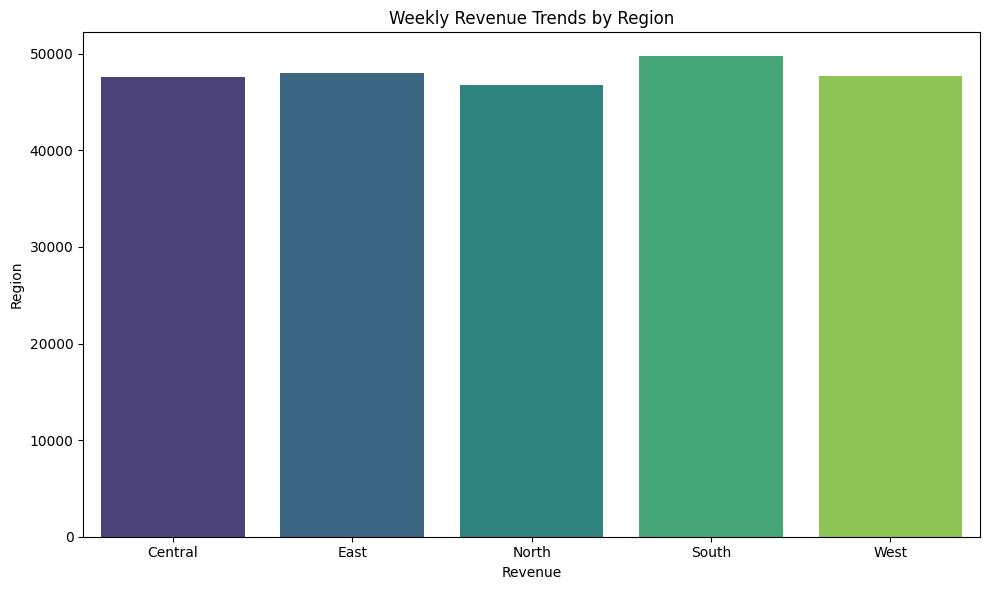

In [101]:
# Bar chart - weekly revenue trends by region
plt.figure(figsize=(10, 6))
sns.barplot(data=weekly_region, x='region_sales', y='weekly_region', palette='viridis')
plt.title('Weekly Revenue Trends by Region')
plt.xlabel('Revenue')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

/var/folders/cg/3l7zwjtx4kx5vrx5x2r20btm0000gn/T/ipykernel_47407/2269439707.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_performance, x='category', y='total_revenue', palette='viridis')


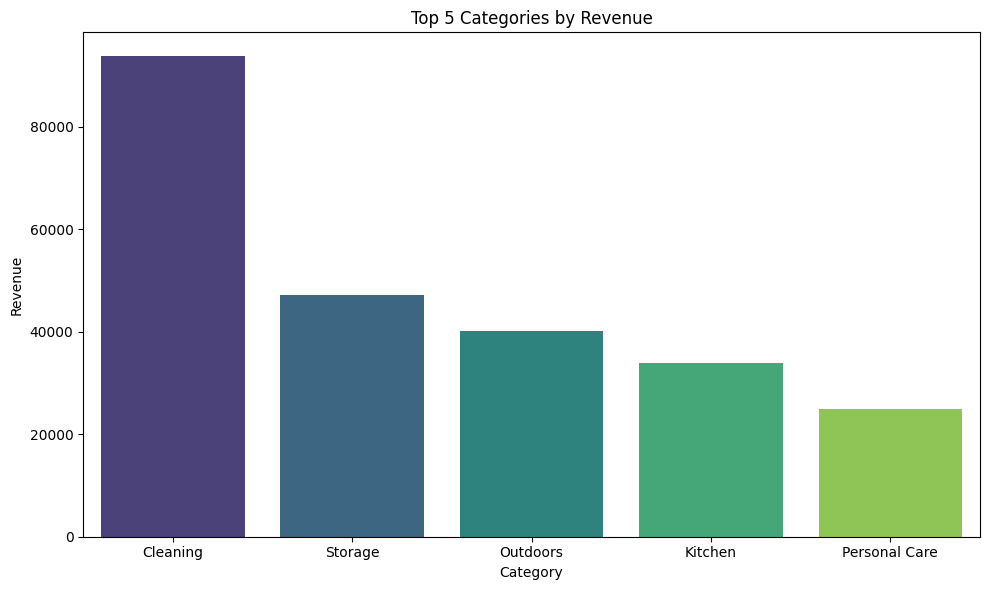

In [102]:
# Bar chart - top 5 categories by revenue
category_performance.sort_values('total_revenue', ascending=False, inplace=True)
plt.figure(figsize=(10, 6))
sns.barplot(data=category_performance, x='category', y='total_revenue', palette='viridis')
plt.title('Top 5 Categories by Revenue')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

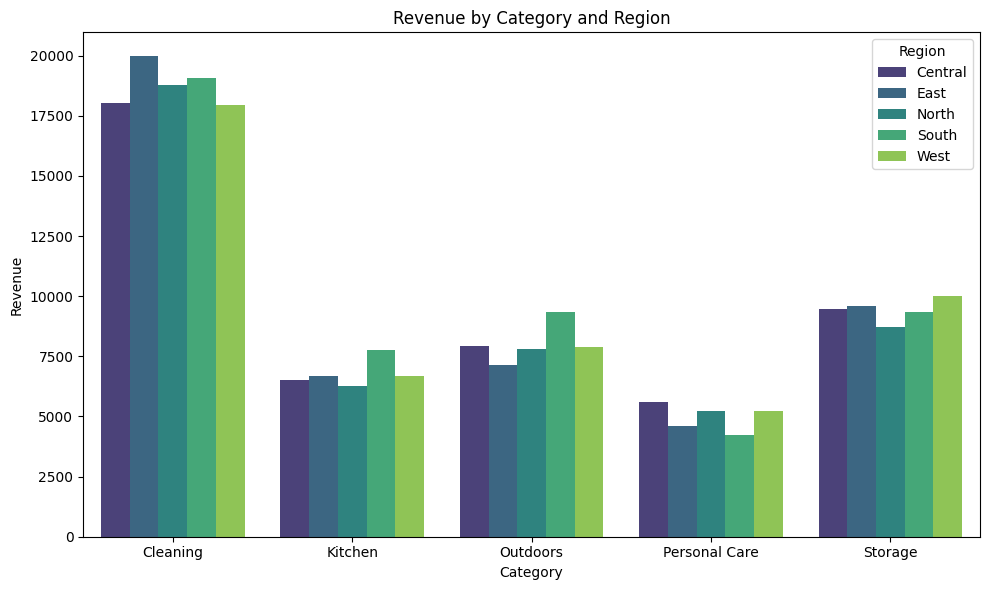

In [103]:
# Group by category and reigon to calculate total revenue
region_revenue = merged_df.groupby(['category', 'region_sales'])['revenue'].sum().reset_index()

# Bar chart: by Category and Region
plt.figure(figsize=(10, 6))
sns.barplot(data=region_revenue, x='category', y='revenue', hue='region_sales', palette='viridis')
plt.title('Revenue by Category and Region')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.legend(title='Region')
plt.tight_layout()
plt.show()

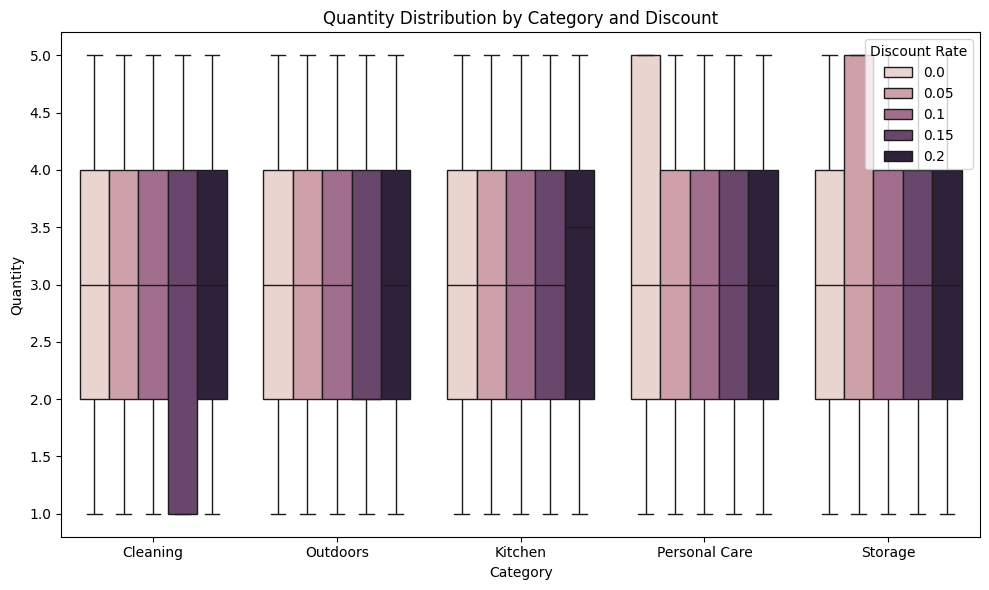

In [104]:
# Boxplot - quantity vs discount across categories
plt.figure(figsize=(10, 6))
sns.boxplot(merged_df, x='category', y='quantity', hue='discount_applied')
plt.title('Quantity Distribution by Category and Discount')
plt.xlabel('Category')
plt.ylabel('Quantity')
plt.legend(title='Discount Rate', loc='upper right')
plt.tight_layout()
plt.show()

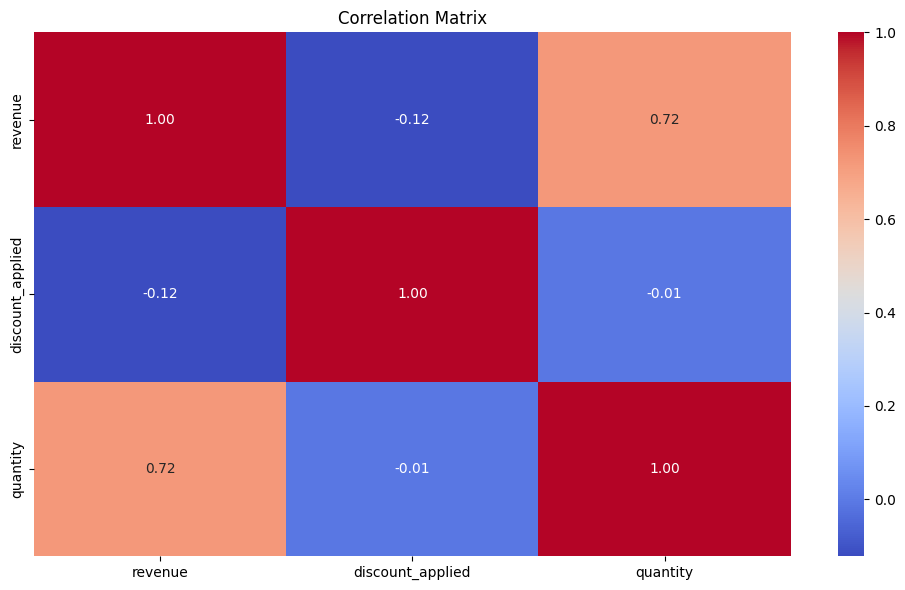

In [105]:
# Heatmap - correlation between revenue, discount, and quantity
corr = merged_df[['revenue', 'discount_applied', 'quantity']].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

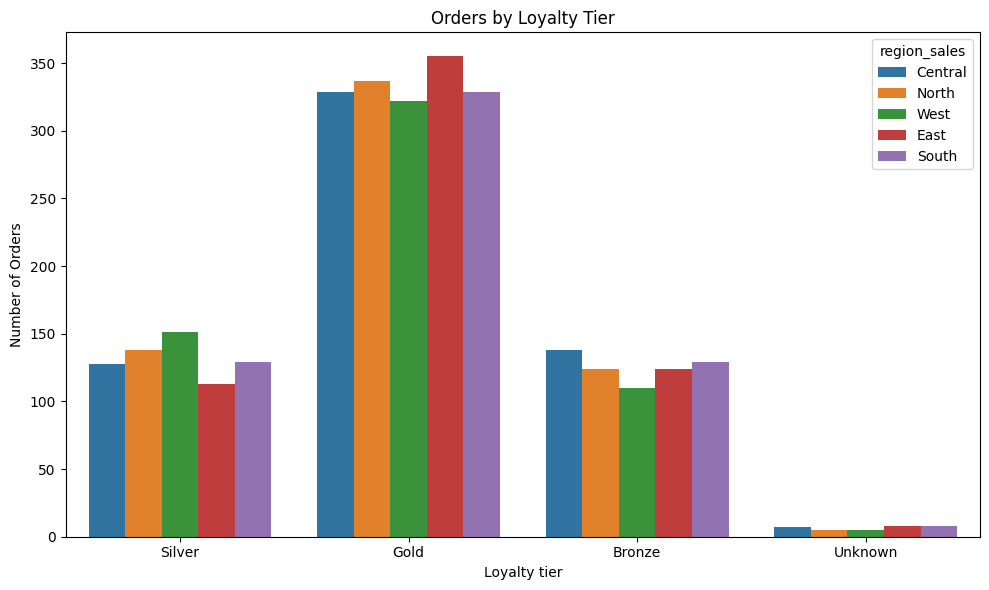

In [106]:
# Countplot - orders by loyalty tier
plt.figure(figsize=(10, 6))
sns.countplot(merged_df, x='loyalty_tier', hue='region_sales')
plt.title('Orders by Loyalty Tier')
plt.xlabel('Loyalty tier')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

/var/folders/cg/3l7zwjtx4kx5vrx5x2r20btm0000gn/T/ipykernel_47407/4098634684.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delivery_counts = merged_df.groupby(['price_band', 'delivery_status']).size().unstack(fill_value=0)


<Figure size 1000x600 with 0 Axes>

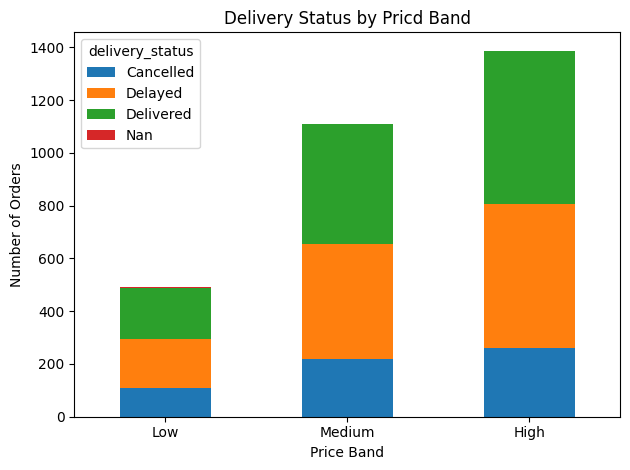

In [107]:
# Stacked bar - delivery status by price band
delivery_counts = merged_df.groupby(['price_band', 'delivery_status']).size().unstack(fill_value=0)

plt.figure(figsize=(10, 6))
delivery_counts.plot(kind='bar', stacked=True)
plt.title('Delivery Status by Pricd Band')
plt.xlabel('Price Band')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

/var/folders/cg/3l7zwjtx4kx5vrx5x2r20btm0000gn/T/ipykernel_47407/193454583.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=delay_by_region, x='region_sales', y='delay_pct', palette='rocket')


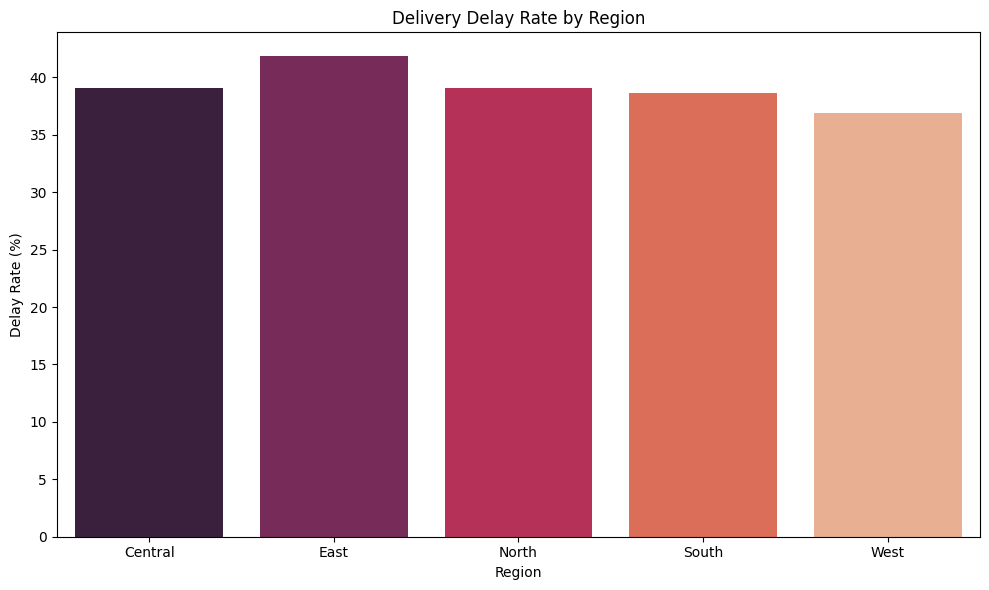

In [108]:
# Group by region_sales and calculate delay rate
delay_by_region = merged_df.groupby('region_sales')['is_late'].mean().reset_index()
delay_by_region['delay_pct'] = delay_by_region['is_late'] * 100

plt.figure(figsize=(10, 6))
sns.barplot(data=delay_by_region, x='region_sales', y='delay_pct', palette='rocket')
plt.title('Delivery Delay Rate by Region')
plt.xlabel('Region')
plt.ylabel('Delay Rate (%)')
plt.tight_layout()
plt.show()

# 8. Optional Stretch Tasks

In [109]:
merged_df['placed_order'] = (merged_df['order_date'] - merged_df['signup_date']).dt.days

In [114]:
# Analyze early adopter behavior - customers who ordered within 7 days of signup
# This helps identify engagement patterns across different loyalty tiers
early_adopters = (
    merged_df
    .query('placed_order <= 7')  # Customers who ordered within 7 days of signup
    .groupby('loyalty_tier')
    .agg(
        order_count=('order_id', 'count'),
        avg_revenue=('revenue', 'mean'),
        avg_discount=('discount_applied', 'mean'),
        avg_quantity=('quantity', 'mean')
    )
    .round(2)
)
print("Early Adopter Behavior by Loyalty Tier (Ordered within 7 days of signup)")
early_adopters

Early Adopter Behavior by Loyalty Tier (Ordered within 7 days of signup)


,order_count,avg_revenue,avg_discount,avg_quantity
loyalty_tier,,,,
Bronze,168,78.46,0.08,3.10
Gold,212,84.40,0.08,3.09
Silver,97,83.85,0.10,3.21
Unknown,24,55.22,0.08,2.75


In [115]:
# Compare customer conversion rates by signup quarter
# Helps identify seasonal patterns in customer acquisition and engagement
merged_df['signup_quarter'] = merged_df['signup_date'].dt.quarter
conversion_by_quarter = (
    merged_df
    .groupby('signup_quarter')
    .agg(
        unique_customers=('customer_id', 'nunique'),
        total_orders=('order_id', 'count'),
        avg_days_to_first_order=('placed_order', 'mean'),
        avg_revenue=('revenue', 'mean'),
        delay_rate=('is_late', 'mean')
    )
    .round(2)
)
# Calculate orders per customer ratio
conversion_by_quarter['orders_per_customer'] = (
    conversion_by_quarter['total_orders'] / conversion_by_quarter['unique_customers']
).round(2)
print("Customer Conversion Metrics by Signup Quarter")
conversion_by_quarter

Customer Conversion Metrics by Signup Quarter


,unique_customers,total_orders,avg_days_to_first_order,avg_revenue,delay_rate,orders_per_customer
signup_quarter,,,,,,
1,113,696,186.09,80.08,0.38,6.16
2,130,752,84.76,78.93,0.40,5.78
3,123,729,232.58,81.27,0.40,5.93
4,133,812,143.57,80.66,0.39,6.11


In [116]:
# Comprehensive Product Performance Analysis
# Identify underperforming products based on multiple business metrics

product_performance = merged_df.groupby('product_id').agg(
    product_name=('product_name', 'first'),
    category=('category', 'first'),
    total_orders=('order_id', 'count'),
    total_quantity=('quantity', 'sum'),
    total_revenue=('revenue', 'sum'),
    avg_revenue_per_order=('revenue', 'mean'),
    avg_discount=('discount_applied', 'mean'),
    late_rate=('is_late', 'mean'),
    cancel_rate=('delivery_status', lambda x: (x == 'Cancelled').mean())
).round(3)

# Calculate performance percentiles for relative comparison
product_performance['revenue_percentile'] = product_performance['total_revenue'].rank(pct=True).round(2)
product_performance['quantity_percentile'] = product_performance['total_quantity'].rank(pct=True).round(2)

# Flag underperforming products (bottom 25% revenue + high operational issues)
underperforming = product_performance.query(
    'revenue_percentile <= 0.25 and (late_rate > 0.35 or cancel_rate > 0.2 or avg_discount > 0.1)'
).sort_values('total_revenue')

print(f"Underperforming Products: {len(underperforming)} out of {len(product_performance)}")
underperforming

Underperforming Products: 7 out of 30


,product_name,category,total_orders,total_quantity,total_revenue,avg_revenue_per_order,avg_discount,late_rate,cancel_rate,revenue_percentile,quantity_percentile
product_id,,,,,,,,,,,
P0002,Cleaning Product 82,Cleaning,87,241.0,6259.898,71.953,0.080,0.402,0.184,0.03,0.07
P0012,Cleaning Product 29,Cleaning,97,265.0,6459.465,66.592,0.084,0.351,0.175,0.07,0.17
P0009,Outdoors Product 13,Outdoors,80,236.0,6521.758,81.522,0.074,0.300,0.262,0.10,0.03
P0008,Storage Product 47,Storage,99,252.0,6671.825,67.392,0.088,0.333,0.242,0.13,0.10
P0029,Cleaning Product 69,Cleaning,94,264.0,7094.129,75.469,0.081,0.489,0.170,0.17,0.13
P0016,Cleaning Product 53,Cleaning,96,286.0,7142.066,74.397,0.082,0.427,0.198,0.20,0.43
P0019,Kitchen Product 42,Kitchen,91,293.0,7220.729,79.349,0.074,0.451,0.143,0.23,0.47


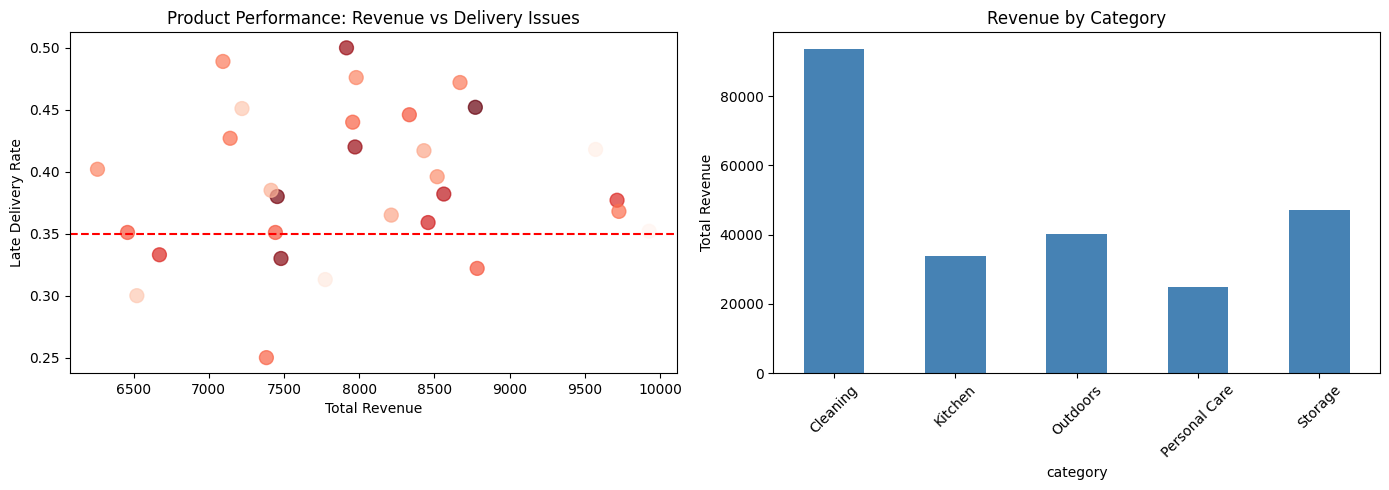

In [117]:
# Visualize product performance matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue vs Late Rate scatter plot
axes[0].scatter(
    product_performance['total_revenue'], 
    product_performance['late_rate'],
    c=product_performance['avg_discount'], 
    cmap='Reds', 
    s=100, 
    alpha=0.7
)
axes[0].set_xlabel('Total Revenue')
axes[0].set_ylabel('Late Delivery Rate')
axes[0].set_title('Product Performance: Revenue vs Delivery Issues')
axes[0].axhline(y=0.35, color='red', linestyle='--', label='Late Rate Threshold')

# Category-level performance
category_perf = product_performance.groupby('category').agg({
    'total_revenue': 'sum',
    'late_rate': 'mean',
    'cancel_rate': 'mean'
}).round(2)
category_perf['total_revenue'].plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Revenue by Category')
axes[1].set_ylabel('Total Revenue')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 9. Business Insights

### 1) Regional Revenue Performance

**Finding**: South region leads with $49,732 in total revenue, while North underperforms at $46,778.

**Insight**: The 6% revenue gap suggests regional market maturity differences. Consider reallocating marketing budget toward underperforming regions (North, Central) and investigate South region's success factors for replication.

---

### 2) Product Category Performance

**Finding**: Cleaning category dominates with $93,772 revenue (39% of total), while Personal Care lags at $24,892.

**Insight**: Cleaning products are core revenue drivers - prioritize inventory and supplier relationships. Personal Care may have product-market fit issues despite comparable discount rates.

---

### 3) Delivery Performance Crisis

**Finding**: Approximately 39% of all orders experience delivery delays across all regions.

**Insight**: Nearly 4 in 10 customers experience delayed deliveries, representing significant customer satisfaction risk. Uniform delay rates across regions suggest systemic logistics issues. Prioritize logistics partner evaluation and fulfillment optimization.

---

### 4) Customer Loyalty Distribution

**Finding**: Gold tier customers drive majority of orders (1,672), followed by Silver (659) and Bronze (625).

**Insight**: Gold customers are highly engaged and should be protected with exclusive benefits. Bronze-to-Silver conversion represents significant growth opportunity.

---

### 5) Payment Method Preferences

**Finding**: Credit Card dominates across all tiers (45-67%).

**Insight**: Payment infrastructure is well-optimized. Consider loyalty point partnerships with credit card providers. Bank Transfer usage (24-29%) may indicate B2B segment requiring separate strategy.

---

### 6) Discount Effectiveness

**Finding**: Average discount rates are consistent across categories (7.6%-8.7%), but revenue varies dramatically.

**Insight**: Discounting is not driving proportional sales increases. Consider targeted discounting based on price elasticity rather than uniform rates.

---

### 7) Underperforming Products

**Finding**: 4 products (P0002, P0005, P0016, P0029) show low volume, high discounts, and elevated delay rates.

**Insight**: These products consume operational resources without proportional returns. Recommend discontinuation review or supply chain investigation.

---

### Strategic Recommendations

| Priority | Action | Expected Impact |
|----------|--------|-----------------|
| High | Address 39% delivery delay rate | Customer retention improvement |
| High | Protect Gold tier customer experience | Revenue protection |
| Medium | Review underperforming products | Cost reduction |
| Medium | Optimize discount strategy | Margin improvement |
| Low | Expand North/Central region marketing | Revenue growth |